Linear regression

with Scikit-Learn:

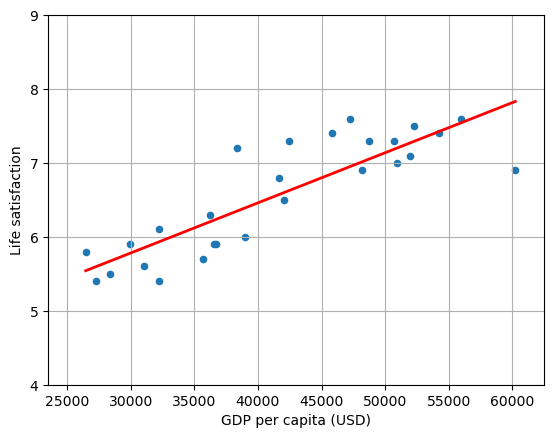

[[6.30165767]]
Mean Absolute Percentage Error: 4.7780028161206065 %


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

data_frame = pd.read_csv("https://github.com/ageron/data/raw/main/lifesat/lifesat.csv")

x_values = data_frame[["GDP per capita (USD)"]].values
y_values = data_frame[["Life satisfaction"]].values

data_frame.plot(kind='scatter', grid=True, x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])

model = LinearRegression()
model.fit(x_values, y_values)

y_predictions = model.predict(x_values)
plt.plot(x_values, y_predictions, color='red', linewidth=2, label="Predictions")
plt.show()

x_cyprus = [[37_655.2]]
print(model.predict(x_cyprus))

mape = np.mean(np.abs((y_values - y_predictions) / y_values)) * 100

print("Mean Absolute Percentage Error:", mape, "%")


with Pytorch: (wait gradient descent chapter, it's required normalization here)

Epoch [1000/5000], Loss: 0.2727
Epoch [2000/5000], Loss: 0.2727
Epoch [3000/5000], Loss: 0.2727
Epoch [4000/5000], Loss: 0.2727
Epoch [5000/5000], Loss: 0.2727


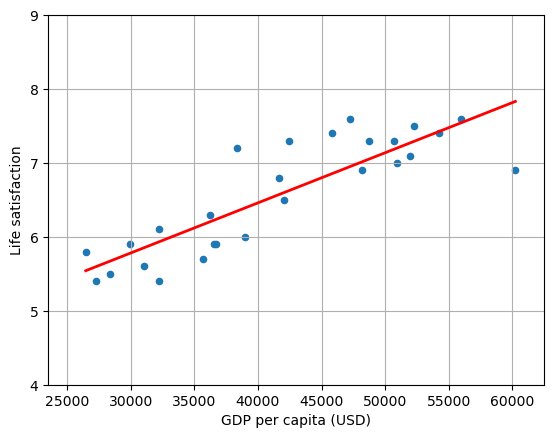

Life satisfaction predicted for Cyprus: 6.30


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

# Caricamento dati
data_frame = pd.read_csv("https://github.com/ageron/data/raw/main/lifesat/lifesat.csv")

# Variabili indipendenti e dipendenti
x_values = data_frame[["GDP per capita (USD)"]].values
y_values = data_frame[["Life satisfaction"]].values

# Normalizzazione
x_mean = x_values.mean()
x_std = x_values.std()
y_mean = y_values.mean()
y_std = y_values.std()

x_norm = (x_values - x_mean) / x_std
y_norm = (y_values - y_mean) / y_std

# Conversione in tensori PyTorch
x_tensor = torch.tensor(x_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32)

# Modello lineare
linear_model = nn.Linear(1, 1)

# Funzione di loss e ottimizzatore
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(linear_model.parameters(), lr=0.01)

# Training
num_epochs = 5000
for epoch in range(num_epochs):
    y_pred = linear_model(x_tensor)
    loss = loss_function(y_pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Predizioni e conversione scala originale
y_pred_tensor = linear_model(x_tensor).detach().numpy()
y_pred_real = y_pred_tensor * y_std + y_mean

# Visualizzazione
data_frame.plot(kind='scatter', grid=True, x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.plot(x_values, y_pred_real, color='red', linewidth=2, label="Predictions")
plt.show()

# Predizione per Cipro
x_cyprus_norm = (37_655.2 - x_mean) / x_std
x_cyprus_tensor = torch.tensor([[x_cyprus_norm]], dtype=torch.float32)
y_cyprus_pred_norm = linear_model(x_cyprus_tensor).item()
y_cyprus_pred = y_cyprus_pred_norm * y_std + y_mean
print(f"Life satisfaction predicted for Cyprus: {y_cyprus_pred:.2f}")